In [16]:
import numpy as np

def softmax(x, axis=-1):
    """Numerically stable softmax."""
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    """Compute scaled dot-product attention."""
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores)
    output = weights @ V
    return output, weights

# Simulate a 3-word sequence with d_k = 4 dimensional Q, K, V vectors
np.random.seed(42)
d_k = 4
words = ["The", "cat", "sleeps","Sofa"]

Q = np.random.randn(4, d_k)
K = np.random.randn(4, d_k)
V = np.random.randn(4, d_k)

output, attention_weights = scaled_dot_product_attention(Q, K, V)

print("Attention Weight Matrix (each row sums to 1.0):")
print(f"{'':12s} {'Key: The':>12s} {'Key: cat':>12s} {'Key: sleeps':>12s} {'Key: sofa':>12s}")
for i, word in enumerate(words):
    row = " ".join([f"{w:12.4f}" for w in attention_weights[i]])
    print(f"Query: {word:<6s} {row}")

print(f"\nRow sums (should all be 1.0): {attention_weights.sum(axis=-1)}")
print(f"Output shape: {output.shape}")

Attention Weight Matrix (each row sums to 1.0):
                 Key: The     Key: cat  Key: sleeps    Key: sofa
Query: The          0.0434       0.1133       0.1783       0.6650
Query: cat          0.1128       0.1934       0.1793       0.5145
Query: sleeps       0.4323       0.1670       0.2557       0.1450
Query: Sofa         0.2846       0.2786       0.2729       0.1638

Row sums (should all be 1.0): [1. 1. 1. 1.]
Output shape: (4, 4)


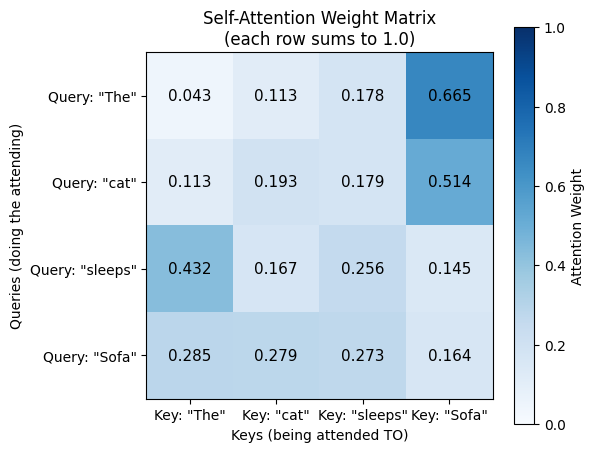


What does this tell us?
  Highest attention: 'The' attends most strongly to 'Sofa' (0.665)


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(attention_weights, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Attention Weight')

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels([f'Key: "{w}"' for w in words])
ax.set_yticklabels([f'Query: "{w}"' for w in words])
ax.set_title("Self-Attention Weight Matrix\n(each row sums to 1.0)")
ax.set_xlabel("Keys (being attended TO)")
ax.set_ylabel("Queries (doing the attending)")

# Annotate each cell with its value
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{attention_weights[i, j]:.3f}",
                ha='center', va='center', color='black', fontsize=11)

plt.tight_layout()
plt.show()

print("\nWhat does this tell us?")
max_pair = np.unravel_index(attention_weights.argmax(), attention_weights.shape)
print(f"  Highest attention: '{words[max_pair[0]]}' attends most strongly to '{words[max_pair[1]]}' ({attention_weights[max_pair]:.3f})")

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_attention_classifier(seq_len, d_model, num_heads, d_proj=None):
    """
    Binary sentiment classifier using self-attention.

    Args:
        seq_len   : maximum sequence length (number of tokens)
        d_model   : input embedding dimension (250 for Wiki-words)
        num_heads : number of parallel attention heads
        d_proj    : if set, projects embeddings to this dimension before attention
    """
    inputs = layers.Input(shape=(seq_len, d_model), name="word_embeddings")
    x = inputs

    # Optional projection: compress large embeddings to a smaller d_model
    if d_proj is not None:
        x = layers.Dense(d_proj, use_bias=False, name="input_projection")(x)
        key_dim = d_proj // num_heads
    else:
        key_dim = d_model // num_heads

    # Self-attention: every word attends to every other word simultaneously
    x = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        name="self_attention"
    )(x, x)

    # Collapse the sequence dimension — identical role to the LSTM's final hidden state
    x = layers.GlobalAveragePooling1D(name="sequence_avg")(x)

    # Binary classification output
    outputs = layers.Dense(1, activation='sigmoid', name="sentiment_output")(x)

    return Model(inputs=inputs, outputs=outputs, name="Attention_Classifier")


# Full-size model — matches the Wiki-words embedding dimension from Course 2
SEQ_LEN  = 59   # max token length from Course 2's Sentiment Dataset
D_MODEL  = 250  # Wiki-words embedding dimension
NUM_HEADS = 2

full_model = build_attention_classifier(SEQ_LEN, D_MODEL, NUM_HEADS)
print("=== Full-Size Attention Classifier ===")
full_model.summary()

=== Full-Size Attention Classifier ===


Model: "Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_embeddings     │ (None, 59, 250)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 59, 250)   │    251,000 │ word_embeddings[… │
│ (MultiHeadAttentio… │                   │            │ word_embeddings[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_avg        │ (None, 250)       │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │        251 │ sequence_avg[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 251,251 (981.45 KB)

 Trainable params: 251,251 (981.45 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
import pandas as pd
import numpy as np
import tensorflow_hub as hub
import kagglehub
import os

# 1. Load the Data
dataset_path = "/content/drive/MyDrive/amazon_cells_labelled.csv"

# The dataset has multiple columns due to trailing commas (e.g., text, label, empty, empty...).
# We will read it with comma separation, and then keep only the first two columns.
try:
    df = pd.read_csv(dataset_path, header=None, on_bad_lines='skip')
    # Select the first two columns and rename them
    df = df.iloc[:, [0, 1]]
    df.columns = ['text', 'label']
    # Ensure labels are integers
    df['label'] = pd.to_numeric(df['label'], errors='coerce')
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
except Exception as e:
    print(f"Error parsing dataset: {e}")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [22]:
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
embed = hub.load(model_path)

# 3. Preprocessing helpers (identical to Course 2)
def get_max_length(df):
    return max(len(row.split()) for row in df['text'])

def get_word2vec_enc(texts):
    return [embed(text.split()) for text in texts]

def get_padded_encoded_texts(encoded_texts, max_len):
    padded = []
    pad = np.zeros((1, 250))
    for enc in encoded_texts:
        n_pad = max_len - enc.shape[0]
        for _ in range(n_pad):
            enc = np.concatenate((pad, enc), axis=0)
        padded.append(enc)
    return padded

def preprocess(df, max_len):
    encoded = get_word2vec_enc(df['text'].tolist())
    padded  = get_padded_encoded_texts(encoded, max_len)
    return np.array(padded), np.array(df['label'].tolist())

# 4. Use only the first 200 samples for the tiny illustration
df_tiny = df.head(200).reset_index(drop=True)
max_len  = get_max_length(df)   # keep same max_len as full dataset for shape consistency
print(f"Max sequence length: {max_len}")

X_tiny, Y_tiny = preprocess(df_tiny, max_len)
print(f"Tiny X shape: {X_tiny.shape}  — (samples, seq_len, embed_dim)")
print(f"Tiny Y shape: {Y_tiny.shape}")


100%|██████████| 218/218 [00:00<00:00, 304kB/s]



100%|██████████| 23.0k/23.0k [00:00<00:00, 1.82MB/s]



  0%|          | 0.00/963M [00:00<?, ?B/s]



  0%|          | 0.00/8.27M [00:00<?, ?B/s]

 12%|█▏        | 1.00M/8.27M [00:01<00:10, 750kB/s]
  0%|          | 1.00M/963M [00:01<22:53, 734kB/s]

 24%|██▍       | 2.00M/8.27M [00:01<00:04, 1.46MB/s]
  0%|          | 2.00M/963M [00:01<11:44, 1.43MB/s]

 36%|███▋      | 3.00M/8.27M [00:01<00:02, 2.32MB/s]
  0%|          | 3.00M/963M [00:01<07:23, 2.27MB/s]
  0%|          | 4.00M/963M [00:01<05:07, 3.27MB/s]

 60%|██████    | 5.00M/8.27M [00:01<00:00, 4.28MB/s]
  1%|          | 6.00M/963M [00:02<02:58, 5.60MB/s]

100%|██████████| 8.27M/8.27M [00:02<00:00, 4.05MB/s]

  1%|          | 8.00M/963M [00:02<02:05, 8.00MB/s]
  1%|          | 10.0M/963M [00:02<01:40, 9.89MB/s]
  1%|          | 12.0M/963M [00:02<01:26, 11.6MB/s]
  1%|▏         | 14.0M/963M [00:02<01:17, 12.9MB/s]
  2%|▏         | 16.0M/963M [00:02<01:12, 13.6MB/s]
  2%|▏         | 18.0M/963M [00:02<01:07, 14.7MB/s]
  2%|▏         | 20.0M/963M [00:02<01:06, 14.9MB/s]
  2%|▏         | 22.0M/963M [00:03<01:01, 15.9MB/s]
  2%|▏   

Max sequence length: 30
Tiny X shape: (200, 30, 250)  — (samples, seq_len, embed_dim)
Tiny Y shape: (200,)


In [23]:
#Build the tiny illustration model
# d_proj=16 compresses the 250-dim embeddings before attention — keeps training fast
tiny_model = build_attention_classifier(
    seq_len=max_len,
    d_model=250,
    num_heads=2,
    d_proj=16      # project 250 → 16 dimensions for a lightweight illustration
)

print("=== Tiny Illustration Model ===")
tiny_model.summary()

tiny_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nStarting tiny training run (200 samples, 5 epochs)...")
tiny_history = tiny_model.fit(
    X_tiny, Y_tiny,
    epochs=5,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

=== Tiny Illustration Model ===


Model: "Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_embeddings     │ (None, 30, 250)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 30, 16)    │      4,000 │ word_embeddings[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 30, 16)    │      1,088 │ input_projection… │
│ (MultiHeadAttentio… │                   │            │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_avg        │ (None, 16)        │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         17 │ sequence_avg[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,105 (19.94 KB)

 Trainable params: 5,105 (19.94 KB)

 Non-trainable params: 0 (0.00 B)


Starting tiny training run (200 samples, 5 epochs)...
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.4688 - loss: 0.6935 - val_accuracy: 0.4750 - val_loss: 0.6934
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5125 - loss: 0.6927 - val_accuracy: 0.4750 - val_loss: 0.6936
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5625 - loss: 0.6923 - val_accuracy: 0.4750 - val_loss: 0.6936
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5312 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5125 - loss: 0.6899 - val_accuracy: 0.4750 - val_loss: 0.6952


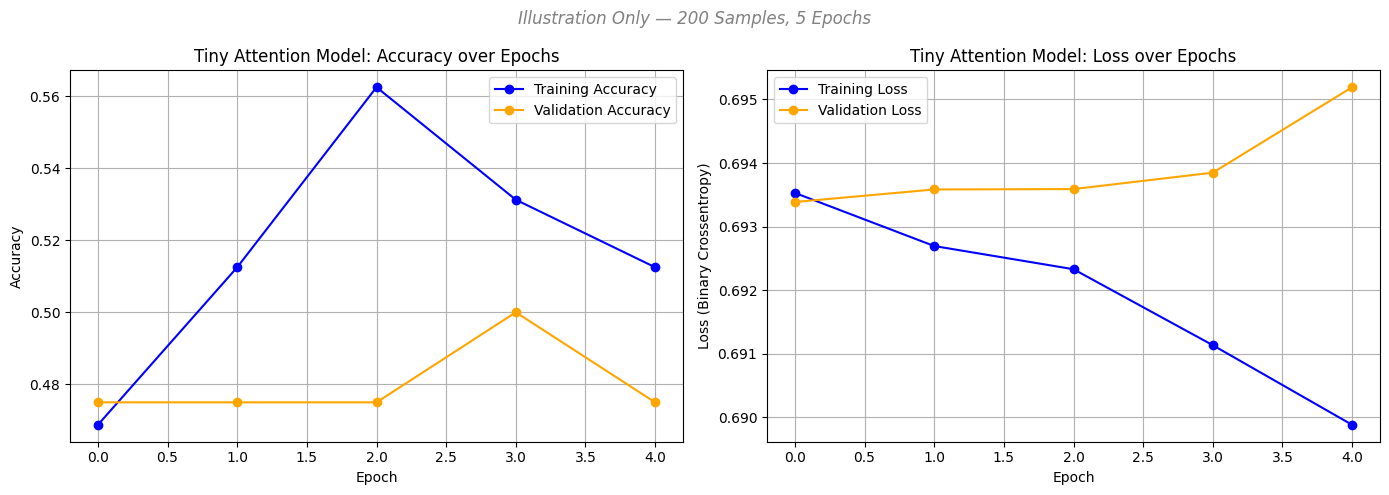


Key observation: the training loss decreased — self-attention trains successfully!
Final training loss:   0.6899
Final training accuracy: 0.5125


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(tiny_history.history['accuracy'],     label='Training Accuracy',   color='blue',   marker='o')
ax1.plot(tiny_history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Tiny Attention Model: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(tiny_history.history['loss'],     label='Training Loss',   color='blue',   marker='o')
ax2.plot(tiny_history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Tiny Attention Model: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Illustration Only — 200 Samples, 5 Epochs', fontstyle='italic', color='gray')
plt.tight_layout()
plt.show()

print("\nKey observation: the training loss decreased — self-attention trains successfully!")
print(f"Final training loss:   {tiny_history.history['loss'][-1]:.4f}")
print(f"Final training accuracy: {tiny_history.history['accuracy'][-1]:.4f}")

Positional encoding

In [ ]:
import numpy as np

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def attention_scores(X):
    """Compute raw self-attention scores for an embedding matrix X."""
    d_k = X.shape[-1]
    scores = X @ X.T / np.sqrt(d_k)
    return softmax(scores)

np.random.seed(7)
# Imagine two word embeddings: embedding for position 0 and position 1
emb_word_A = np.array([0.9, 0.1, 0.4, 0.7])   # e.g. "dog"
emb_word_B = np.array([0.2, 0.8, 0.6, 0.3])   # e.g. "man"

# Original order: [dog, man]
X_original = np.stack([emb_word_A, emb_word_B])
# Swapped order: [man, dog]
X_swapped  = np.stack([emb_word_B, emb_word_A])

scores_original = attention_scores(X_original)
scores_swapped  = attention_scores(X_swapped)

print("Attention weights — original order [dog, man]:")
print(scores_original.round(4))
print("\nAttention weights — swapped order [man, dog]:")
print(scores_swapped.round(4))
print("\nAre they the same? (just row/column permuted):", np.allclose(scores_original, scores_swapped[[1,0],:][:,[1,0]]))

In [ ]:
import tensorflow as tf
import numpy as np

class PositionalEncoding(tf.keras.layers.Layer):
    """
    Adds fixed sine/cosine positional signals to word embeddings.
    Has zero trainable parameters.
    """

    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model
        # Pre-compute the full PE matrix once at construction time
        self.pe = self._build_pe_matrix(max_len, d_model)  # (1, max_len, d_model)

    def _build_pe_matrix(self, max_len, d_model):
        """Compute the positional encoding matrix using vectorized NumPy."""
        positions = np.arange(max_len)[:, np.newaxis]          # (max_len, 1)
        i_indices  = np.arange(d_model // 2)[np.newaxis, :]    # (1, d_model/2)

        # Denominator: 10000^(2i / d_model)
        denominator = np.power(10000.0, (2 * i_indices) / d_model)
        angles = positions / denominator                        # (max_len, d_model/2)

        # Interleave: even dimensions → sin, odd dimensions → cos
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angles)
        pe[:, 1::2] = np.cos(angles)

        return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)  # (1, max_len, d_model)

    def call(self, x):
        """Add positional encoding to the input embedding tensor."""
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]

    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.max_len, "d_model": self.d_model})
        return config

  # Quick sanity check
pe_layer = PositionalEncoding(max_len=10, d_model=8)
dummy_emb = tf.zeros((1, 10, 8))          # batch=1, seq_len=10, d_model=8
pe_output  = pe_layer(dummy_emb)
print("Input shape:  ", dummy_emb.shape)
print("Output shape: ", pe_output.shape)
print("Output is no longer all zeros (PE added):")
print(pe_output[0, :3, :].numpy().round(4))  # First 3 positions, all 8 dim


In [ ]:
from tensorflow.keras import layers, Model

def build_pe_classifier(vocab_size, max_len, d_model, num_heads):
    """
    Sentiment classifier: Embedding → PositionalEncoding → MultiHeadAttention → Dense.

    Args:
        vocab_size : number of unique tokens in the vocabulary
        max_len    : maximum sequence length (tokens)
        d_model    : embedding dimension (also the attention model dimension)
        num_heads  : number of parallel attention heads
    """
    inputs = layers.Input(shape=(max_len,), dtype=tf.int32, name="token_ids")

    # 1. Learnable word embedding (maps integer IDs to dense vectors)
    x = layers.Embedding(vocab_size, d_model, name="word_embedding")(inputs)

    # 2. Add fixed positional encoding — no extra trainable weights
    x = PositionalEncoding(max_len=max_len, d_model=d_model, name="positional_encoding")(x)

    # 3. Self-attention
    x = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        name="self_attention"
    )(x, x)

    # 4. Collapse sequence dimension
    x = layers.GlobalAveragePooling1D(name="sequence_avg")(x)

    # 5. Binary classification
    outputs = layers.Dense(1, activation='sigmoid', name="sentiment_output")(x)

    return Model(inputs=inputs, outputs=outputs, name="PE_Attention_Classifier")


# Build with the tiny illustration dimensions from the issue
VOCAB_SIZE = 5000
MAX_LEN    = 60
D_MODEL    = 32
NUM_HEADS  = 2

model = build_pe_classifier(VOCAB_SIZE, MAX_LEN, D_MODEL, NUM_HEADS)
model.summary()

In [ ]:
df_tiny = df.head(200).reset_index(drop=True)
texts_tiny  = df_tiny['text'].tolist()
labels_tiny = df_tiny['label'].tolist()

# 3. Build vocabulary with TextVectorization (fit on full dataset for realistic vocab)
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
vectorizer.adapt(df['text'].tolist())   # fit vocabulary on full dataset
print(f"Vocabulary size: {len(vectorizer.get_vocabulary())}")

# 4. Vectorize the tiny subset into integer token sequences
X_tiny = vectorizer(texts_tiny).numpy()    # (200, MAX_LEN) integer matrix
Y_tiny = np.array(labels_tiny)
print(f"X shape: {X_tiny.shape}  — (samples, seq_len)")
print(f"Y shape: {Y_tiny.shape}")
print(f"Example tokenized sentence (first 10 tokens): {X_tiny[0, :10]}")

In [ ]:
import matplotlib.pyplot as plt

# Build and compile the tiny illustration model
tiny_model = build_pe_classifier(VOCAB_SIZE, MAX_LEN, D_MODEL, NUM_HEADS)

tiny_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting tiny training run (200 samples, 5 epochs)...")
history = tiny_model.fit(
    X_tiny, Y_tiny,
    epochs=5,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot learning curves — Course 2 style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Training Accuracy',   color='blue',   marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('PE Classifier: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Training Loss',   color='blue',   marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('PE Classifier: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Illustration Only — 200 Samples, 5 Epochs', fontstyle='italic', color='gray')
plt.tight_layout()
plt.show()

print(f"\nFinal training loss:     {history.history['loss'][-1]:.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print("Key observation: loss decreased — positional encoding trains successfully!")

In [ ]:
# Generate a PE matrix for 50 positions with 64 dimensions for a clear visualization
pe_vis = PositionalEncoding(max_len=50, d_model=64)
dummy_input = tf.zeros((1, 50, 64))
pe_matrix = pe_vis(dummy_input)[0].numpy()  # shape (50, 64)

plt.figure(figsize=(10, 6))
plt.imshow(pe_matrix, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Encoding Value')
plt.title("Positional Encoding Matrix\n(50 positions × 64 dimensions)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position in Sequence")
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.tight_layout()
plt.show()

# Show cosine similarity between adjacent positions — they should be close to each other
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("Cosine similarity between adjacent positions (should be high — nearby positions are similar):")
for pos in [0, 5, 10, 20]:
    sim = cosine_similarity(pe_matrix[pos], pe_matrix[pos + 1])
    print(f"  Position {pos:2d} ↔ {pos+1:2d}: {sim:.4f}")

print("\nCosine similarity between distant positions (should be lower):")
for pair in [(0, 10), (0, 25), (0, 49)]:
    sim = cosine_similarity(pe_matrix[pair[0]], pe_matrix[pair[1]])
    print(f"  Position {pair[0]:2d} ↔ {pair[1]:2d}: {sim:.4f}")